## 8.1 学习率衰减策略 - 等间隔学习率衰减

#### 1. 为什么还需要手动学习率调整
在前面的优化算法中，我们已经学习了：
* Momentum
* AdaGrad
* RMSProp
* Adam

这些方法都会在训练过程中，自动对更新步长做一定调整。

但是要注意：

这些优化算法并不等于“完全替代学习率设计”。

也就是说，即使我们已经使用了：

`Adam / RMSProp / Momentum`

我们仍然通常需要：
* 手动控制整体学习率的变化趋势
* 因为在神经网络训练中，学习率对训练效果影响非常大。

##### 1.1 为什么不能一直使用固定学习率
假设训练一开始使用学习率：lr = 0.01 

如果从头到尾都保持不变，可能会出现两个问题：

**情况一：前期合适，后期太大**

训练前期：
* 需要快速下降

较大的学习率有利于：
* 快速靠近较优区域

但训练后期：
* 需要精细调整参数

如果学习率仍然太大，就可能出现：
* 在最优点附近来回震荡

**情况二：前期太小，训练过慢**

如果一开始就把学习率设得很小：
* 训练虽然稳定

但会出现：
* 收敛速度很慢

所以更合理的思路是：

前期学习率大一些，后期逐渐减小。

##### 1.2 学习率衰减的核心思想
学习率衰减（Learning Rate Decay）的核心思想就是：
* 训练前期：学习率较大，快速搜索
* 训练后期：学习率较小，精细收敛

这和我们平时下山很像：
* 离目标还远时，可以走快一点 🚶
* 快到目标时，需要放慢脚步，小心靠近 🎯

#### 2. 什么是等间隔学习率衰减
等间隔学习率衰减，英文中常对应：

`Step Decay / StepLR`

它的含义是：

每隔固定的训练轮数（epoch），就把学习率按一定比例减小一次。

例如：
* 初始学习率：0.01
* 每隔 10 个 epoch
* 学习率乘以 0.1

那么学习率变化就是：
```
Epoch 范围	学习率
1 ~ 10	0.01
11 ~ 20	0.001
21 ~ 30	0.0001
```
可以看到：
* 学习率不是连续变化
* 而是“阶梯式下降”

所以它也可以理解为：
* 分段式学习率衰减

#### 3. 等间隔学习率衰减与前面优化器的关系
这里要特别注意：

`学习率衰减策略 和 优化器 是两个不同层面的东西。`

例如：
* 优化器可以是 Adam / SGD / RMSProp
* 学习率调度器可以是 StepLR / ExponentialLR / MultiStepLR

它们可以组合使用。

例如：
```
Adam + StepLR
SGD + StepLR
Momentum + StepLR
```
也就是说：
* 优化器负责“怎么更新参数”
* 调度器负责“学习率怎么变”

这个区分非常重要。


#### 4. 等间隔学习率衰减的数学公式
等间隔学习率衰减常见公式为：

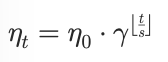

其中：

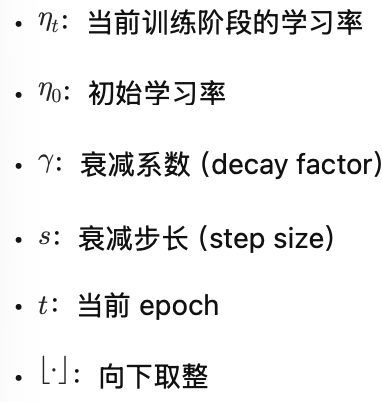

##### 4.1 初始学习率 
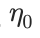

表示：
* 训练刚开始时使用的学习率
例如：
* lr = 0.01 

##### 4.2 衰减系数
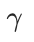

表示：
* 每次衰减后，学习率保留原来的多少

例如：

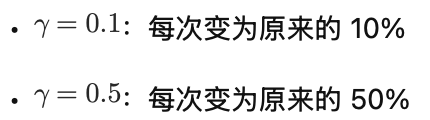

##### 4.3 步长 s
表示：
* 每隔多少个 epoch 衰减一次

例如：
* s = 10：每 10 个 epoch 衰减一次
* s = 5：每 5 个 epoch 衰减一次

#### 5. 等间隔学习率衰减的示例
假设：

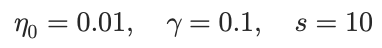

##### 5.1 当 t = 0 - 9

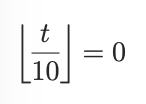

所以：

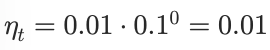

##### 5.2 当 t = 10 - 19

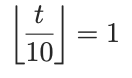

所以：

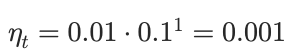

##### 5.3 当 t = 20 - 29

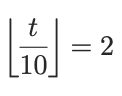

所以：

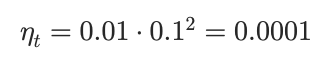

##### 5.4 学习率变化表
```
Epoch	学习率
0 - 9	0.01
10 - 19	0.001
20 - 29	0.0001
30 - 39	0.00001
```
如果把学习率随 epoch 的变化画出来，大致像这样：
```
0.01   ──────────
                 │
0.001            ──────────
                            │
0.0001                      ──────────
```
可以看到它的特点是：
* 在某一段时间内保持不变
* 到了指定间隔后突然下降一档

所以它不是平滑曲线，而是：
* 台阶状变化

这就是典型的：

`阶梯式下降`

#### 6. 等间隔学习率衰减的优点
**1️⃣ 简单直观 ✅**

这种方法非常容易理解：
* 每隔固定 epoch，就降一次学习率
* 逻辑清楚，容易实现。

**2️⃣ 训练控制感强 ✅**

因为衰减时间点是我们自己设定的，所以可以很方便地控制：
* 什么时候开始更细致训练
* 学习率每次降多少

**3️⃣ 实践中非常常见 ✅**

在很多经典深度学习训练任务中，都经常使用这种策略，尤其是在：
* CNN 图像分类
* 传统监督学习训练流程
* 中非常常见。


#### 7. 等间隔学习率衰减的缺点
**1️⃣ 衰减点不够灵活 ⚠️**

它是按固定间隔衰减的：
* 不管模型当前学得好不好
* 到了时间就降

这可能导致：
* 有时候降得太早
* 有时候降得太晚

**2️⃣ 学习率变化不连续 ⚠️**

学习率会突然从一个值跳到另一个值，例如：

`0.01 → 0.001`

这种“突变”有时会让训练过程不够平滑。

**3️⃣ 需要人工设置参数 ⚠️**

我们需要自己决定：
* 初始学习率
* 衰减间隔
* 衰减比例

如果设置不合适，效果也会受影响。

#### 8. 等间隔学习率衰减适合什么场景
这种方法适合：

**1️⃣ 训练轮数比较明确的任务**

例如你知道总共训练 50 个 epoch，那么可以事先规划：
* 第 20 个 epoch 降一次
* 第 40 个 epoch 再降一次

**2️⃣ 模型训练较稳定的场景**

如果模型整体训练比较规律，等间隔衰减通常效果不错。

**3️⃣ 作为入门学习率调度方法**

因为它是最容易理解的学习率衰减策略之一，所以非常适合作为：

学习学习率调度的第一种方法

#### 9. 在 PyTorch 中的实现思路
在 PyTorch 中，等间隔学习率衰减通常使用：

`torch.optim.lr_scheduler.StepLR`

基本思路是：

##### 9.1 先定义优化器 optimizer

In [ ]:
import torch

model = torch.nn.Linear(1, 1)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

##### 9.2 再定义学习率调度器

In [ ]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

其中：
* step_size=10：每 10 个 epoch 衰减一次
* gamma=0.1：每次衰减为原来的 0.1 倍

##### 9.3 每个 epoch 结束后更新调度器

In [ ]:
def train(model, dataloader, optimizer, criterion):

    model.train()

    total_loss = 0

    for x, y in dataloader:

        optimizer.zero_grad()

        y_pred = model(x)

        loss = criterion(y_pred, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(dataloader)

    return train_loss

In [ ]:
for epoch in range(100):
    train(...)
    scheduler.step()